# K-Nearest Neighbour Project
* https://keylabs.ai/blog/k-nearest-neighbors-knn-real-world-applications/ (important link for learning)

# About the Data

We have a dataset from UNICEF with the following variables:
1. Country 
2. Government Revenue as a percentage of GDP
3. Overall expenditure as a percentage of GDP
4. Health Expenditure as a percentage of GDP
5. Education Expenditure as a percentage of GDP
5. Social protection Expenditure as a percentage of GDP
6. Expenditure on Education as a percentage of budget
7. Expenditure on Health as a percentage of budget
8. Expenditure on social protection as percentage of budget
9. ODA inflow 
10.ODA inflow as percentage of GNI
11. ODA Outflow
12. ODA Outflow as a percentage of donor GNI

We have another dataset from World Bank with following variables
1. Country
2. GDP per capita

# What we intend to do?

1. Classification of countries based on their per Capita GDP status (Low Income, Lower Middle, Upper Middle, High) with the given features.
2. What we use ? We use KNN Classification.
3. We verify with the policy targets of National Health Policy 2017 and New Education Policy 2020, can we achieve the Developed Country Status in coming time?

In [1]:
import numpy as np
import pandas as pd

In [56]:
import os
os.getcwd()
#get filenames in the cwd with recent files on the top
recent_files = os.listdir()
recent_files.sort(key=os.path.getmtime, reverse=True)
print(recent_files)

['KNN Project-1.ipynb', 'per capita gdp', 'Economic Indictors_countries_UNICEF.csv', 'Economic Indictors_countries_UNICEF.numbers', '19-Economic-Indicators-SOWC2024.csv', 'Logistic Regression for Advertisment Clicks.ipynb', 'Finance Project EDA.ipynb', 'new_test.ipynb', 'Calls Capstone Project EDA.ipynb', 'Tensorboard on ANN Classification.ipynb', 'logs', 'logs\x0cit', 'Keras-Borrower-Classification-Project.ipynb', 'loan_repayment_model_Neural.keras', 'loan_repayment_model_Neural.h5', 'Untitled-1.ipynb', '03-Keras-Project-Exercise.ipynb', 'my_gem_model.keras', 'my_gem_model.h5', '.DS_Store', 'example.txt', 'example.bin', 'destination.txt', 'temp-plot.html', '01-Recommender Systems with Python.ipynb', '.ipynb_checkpoints', 'College_Data', 'cardekho_imputated.csv', 'auc.png', 'Travel.csv', 'Random Forest Classification Implementation.ipynb', '02-K Nearest Neighbors Project.ipynb', 'all_banks', 'my_picture.png', 'Excel_Sample2.xlsx', 'My_output', 'project.ipynb', 'test.ipynb', 'supermarke

In [214]:
#read csv file downloaded from UNICEF
df = pd.read_csv('Economic Indictors_countries_UNICEF.csv',header=1)
df.rename(columns={'Countries and areas': 'Country'}, inplace=True)
df.head()

,Country,Government revenue as % of GDP\n2015–2023 (R),Over All Expenditure_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,Health_budget,education_budget,social protection_budget,ODA inflow,ODA inflow_GNI,ODA outflow,Ouflow as a % of donor GNI
0,Afghanistan,13.0,21.8,0.7,4.3,1.4,4.1,8.2,6.4,"3,960",26.8,-,NaN
1,Albania,19.3,11.1,2.9,2.7,1.9,9.1,9.8,16.9,339,1.7,-,NaN
2,Algeria,-,16.9,3.3,6.3,2.3,8.8,13.3,13.5,233,0.1,-,NaN
3,Andorra,-,-,6.2,2.7,-,15.7,7.0,-,-,-,-,NaN
4,Angola,21.8,6.4,1.7,2.3,0.5,8.8,7.7,7.7,97,0.1,-,NaN


In [215]:
# read csv file downloaded from World Bank
gdp_df = pd.read_csv('per capita.csv', header=0)
gdp_df.rename(columns={'Country Name':'Country','2023':'GDP per Capita'}, inplace=True)
gdp_df.head()

# Gives the GDP per Capita in USD for the year 2023(Latest year available!)


,Country,GDP per Capita
0,Aruba,33984.7906198041
1,Africa Eastern and Southern,1659.51529015376
2,Afghanistan,415.707417059086
3,Africa Western and Central,1568.72431045118
4,Angola,2308.15976731274


In [216]:
countries_set1 = set(df['Country'])
countries_set2 = set(gdp_df['Country'])
countries_not_found_in_WB_data = [country for country in countries_set1 if country 
                                  not in countries_set2]
print('Countries not found in WB data due to any possible reason: ',len(countries_not_found_in_WB_data))
for country in countries_not_found_in_WB_data:
    print(country)

# We will plug in these values manually! Argh! Data Engineering is painful!
# My dear critics, please don't judge me for this! I am just a human! :P
# If you see ZERO here, it means I have plugged in the value manually!
# It is not a mistake! It is a conscious decision! :P
# I am not a data engineer! I am a data scientist! :P

Countries not found in WB data due to any possible reason:  0


In [221]:
# Finding GDP per capita from world bank data to plug in the UNICEF data
gdp_per_capita = {}
for country in countries_set1:
    gdp_per_capita[country] = gdp_df[gdp_df['Country'] == country]['GDP per Capita'].values[0]

df['GDP per Capita'] = df['Country'].map(gdp_per_capita)   
df.head()


,Country,Government revenue as % of GDP\n2015–2023 (R),Over All Expenditure_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,Health_budget,education_budget,social protection_budget,ODA inflow,ODA inflow_GNI,ODA outflow,Ouflow as a % of donor GNI,GDP per Capita
0,Afghanistan,13.0,21.8,0.7,4.3,1.4,4.1,8.2,6.4,"3,960",26.8,-,NaN,415.707417059086
1,Albania,19.3,11.1,2.9,2.7,1.9,9.1,9.8,16.9,339,1.7,-,NaN,8575.17113446213
2,Algeria,-,16.9,3.3,6.3,2.3,8.8,13.3,13.5,233,0.1,-,NaN,5364.02795022731
3,Andorra,-,-,6.2,2.7,-,15.7,7.0,-,-,-,-,NaN,46812.4484486309
4,Angola,21.8,6.4,1.7,2.3,0.5,8.8,7.7,7.7,97,0.1,-,NaN,2308.15976731274


In [222]:
df.isnull().sum()

# GDP per Capita is missing for 12 countries or regions still!
#  We will plug in the values manually!

Country                                            0
Government revenue as % of GDP\n2015–2023 (R)      0
Over All Expenditure_GDP                           0
Health Expenditure_GDP                             0
Education Expenditure_GDP                          0
social protection expenditure_GDP                  0
Health_budget                                      0
education_budget                                   0
social protection_budget                           0
ODA inflow                                         0
ODA inflow_GNI                                     0
ODA outflow                                        0
Ouflow as a % of donor GNI                       202
GDP per Capita                                    12
dtype: int64

In [223]:
# Who are these 12 countries or regions?
countries_missing_gdp = df[df['GDP per Capita'].isnull()]['Country'].sort_values().values
print('Countries or regions missing GDP per Capita: ',len(countries_missing_gdp))
for country in countries_missing_gdp:
    print(country)

Countries or regions missing GDP per Capita:  12
Bhutan
British Virgin Islands
Cuba
Democratic People's Republic of Korea
Eritrea
Lebanon
Liechtenstein
San Marino
South Sudan
Syrian Arab Republic
Tonga
Venezuela (Bolivarian Republic of)


In [225]:
missing_data = [3711,
47000,
7449,
1217,
3097,
3654,
186400,
53000,
478,
745,
5218,
3738]  # This has been manually extracted from the csv file! Data Engineering is painful! :P

# Fill the missing data by plugging in the values using a for loop
for i in range(len(countries_missing_gdp)):
    df.loc[df['Country'] == countries_missing_gdp[i], 'GDP per Capita'] = missing_data[i]

In [226]:
df.isnull().sum()
# Finally, we have no missing values in the GDP per capita column!

Country                                            0
Government revenue as % of GDP\n2015–2023 (R)      0
Over All Expenditure_GDP                           0
Health Expenditure_GDP                             0
Education Expenditure_GDP                          0
social protection expenditure_GDP                  0
Health_budget                                      0
education_budget                                   0
social protection_budget                           0
ODA inflow                                         0
ODA inflow_GNI                                     0
ODA outflow                                        0
Ouflow as a % of donor GNI                       202
GDP per Capita                                     0
dtype: int64

In [227]:
df.head()

,Country,Government revenue as % of GDP\n2015–2023 (R),Over All Expenditure_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,Health_budget,education_budget,social protection_budget,ODA inflow,ODA inflow_GNI,ODA outflow,Ouflow as a % of donor GNI,GDP per Capita
0,Afghanistan,13.0,21.8,0.7,4.3,1.4,4.1,8.2,6.4,"3,960",26.8,-,NaN,415.707417059086
1,Albania,19.3,11.1,2.9,2.7,1.9,9.1,9.8,16.9,339,1.7,-,NaN,8575.17113446213
2,Algeria,-,16.9,3.3,6.3,2.3,8.8,13.3,13.5,233,0.1,-,NaN,5364.02795022731
3,Andorra,-,-,6.2,2.7,-,15.7,7.0,-,-,-,-,NaN,46812.4484486309
4,Angola,21.8,6.4,1.7,2.3,0.5,8.8,7.7,7.7,97,0.1,-,NaN,2308.15976731274


In [228]:
df.info()
# It is so frustrating to see that the GDP per Capita is an object type!
# We need to convert it to float!
# Converting all the columns to float type requires to remove the '-' sign from the columns
# and then convert them to float type!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Country                                       202 non-null    object 
 1   Government revenue as % of GDP
2015–2023 (R)  202 non-null    object 
 2   Over All Expenditure_GDP                      202 non-null    object 
 3   Health Expenditure_GDP                        202 non-null    object 
 4   Education Expenditure_GDP                     202 non-null    object 
 5   social protection expenditure_GDP             202 non-null    object 
 6   Health_budget                                 202 non-null    object 
 7   education_budget                              202 non-null    object 
 8   social protection_budget                      202 non-null    object 
 9   ODA inflow                                    202 non-null    obj

In [229]:
# Remove the '-' sign from the columns and convert them to float type
df.replace('-', np.nan, inplace=True)

In [230]:
# There are stupid commas too in the numbers! We need to remove them!
df = df.replace(',','', regex=True)
df = df.replace('\$','', regex=True)
df = df.replace('\s','', regex=True)



<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_54289/94439878.py:3: SyntaxWarning: invalid escape sequence '\$'
  df = df.replace('\$','', regex=True)
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_54289/94439878.py:4: SyntaxWarning: invalid escape sequence '\s'
  df = df.replace('\s','', regex=True)


In [231]:
df = df.apply(pd.to_numeric, errors='ignore')# Convert all columns to numeric type, 
#errors='ignore' will ignore the columns that cannot be converted to numeric type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Country                                       202 non-null    object 
 1   Government revenue as % of GDP
2015–2023 (R)  150 non-null    float64
 2   Over All Expenditure_GDP                      168 non-null    float64
 3   Health Expenditure_GDP                        188 non-null    float64
 4   Education Expenditure_GDP                     176 non-null    float64
 5   social protection expenditure_GDP             112 non-null    float64
 6   Health_budget                                 188 non-null    float64
 7   education_budget                              176 non-null    float64
 8   social protection_budget                      168 non-null    float64
 9   ODA inflow                                    139 non-null    flo

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_54289/816573351.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')# Convert all columns to numeric type,


In [232]:
df.head()

,Country,Government revenue as % of GDP\n2015–2023 (R),Over All Expenditure_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,Health_budget,education_budget,social protection_budget,ODA inflow,ODA inflow_GNI,ODA outflow,Ouflow as a % of donor GNI,GDP per Capita
0,Afghanistan,13.0,21.8,0.7,4.3,1.4,4.1,8.2,6.4,3960.0,26.8,NaN,NaN,415.707417
1,Albania,19.3,11.1,2.9,2.7,1.9,9.1,9.8,16.9,339.0,1.7,NaN,NaN,8575.171134
2,Algeria,NaN,16.9,3.3,6.3,2.3,8.8,13.3,13.5,233.0,0.1,NaN,NaN,5364.027950
3,Andorra,NaN,NaN,6.2,2.7,NaN,15.7,7.0,NaN,NaN,NaN,NaN,NaN,46812.448449
4,Angola,21.8,6.4,1.7,2.3,0.5,8.8,7.7,7.7,97.0,0.1,NaN,NaN,2308.159767


In [233]:
# Lets write this dataframe df to a csv file for analysis in the future!
df.to_csv('UNICEF data with NaN.csv', index=False)

In [234]:
df.columns[-2]

'Ouflow as a % of donor GNI'

In [235]:
# We observe that Outflow as a % of donor GNI has all values as NaN
# We will drop this column as it is not useful for analysis
df.drop(df.columns[-2], axis=1, inplace=True)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 13 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Country                                       202 non-null    object 
 1   Government revenue as % of GDP
2015–2023 (R)  150 non-null    float64
 2   Over All Expenditure_GDP                      168 non-null    float64
 3   Health Expenditure_GDP                        188 non-null    float64
 4   Education Expenditure_GDP                     176 non-null    float64
 5   social protection expenditure_GDP             112 non-null    float64
 6   Health_budget                                 188 non-null    float64
 7   education_budget                              176 non-null    float64
 8   social protection_budget                      168 non-null    float64
 9   ODA inflow                                    139 non-null    flo

,Country,Government revenue as % of GDP\n2015–2023 (R),Over All Expenditure_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,Health_budget,education_budget,social protection_budget,ODA inflow,ODA inflow_GNI,ODA outflow,GDP per Capita
0,Afghanistan,13.0,21.8,0.7,4.3,1.4,4.1,8.2,6.4,3960.0,26.8,NaN,415.707417
1,Albania,19.3,11.1,2.9,2.7,1.9,9.1,9.8,16.9,339.0,1.7,NaN,8575.171134
2,Algeria,NaN,16.9,3.3,6.3,2.3,8.8,13.3,13.5,233.0,0.1,NaN,5364.027950
3,Andorra,NaN,NaN,6.2,2.7,NaN,15.7,7.0,NaN,NaN,NaN,NaN,46812.448449
4,Angola,21.8,6.4,1.7,2.3,0.5,8.8,7.7,7.7,97.0,0.1,NaN,2308.159767


In [236]:
# Since our most important column is GDP per Capita, on which we shall construct target classes
# we shall keep the features which are a proportion of GDP i.e Health expenditure as a % of GDP,
# Education expenditure as a % of GDP, Social Protection expenditure as a % of GDP and 
# Overall expenditure as a % of GDP; these shall be retained for analysis.
# We shall drop Health expenditure, Education expenditure, Social Protection expenditure which are a % of budget
# Budget itself is a function of GDP, so we shall drop the expenditure as a % of budget columns
# Hence , lets drop these boring columns!
df.drop(['Health_budget','education_budget','social protection_budget'], axis=1, inplace=True)

In [237]:
df.head() # Keep relooking at the data to see if it is shaping up as per our expectations!

,Country,Government revenue as % of GDP\n2015–2023 (R),Over All Expenditure_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,ODA inflow,ODA inflow_GNI,ODA outflow,GDP per Capita
0,Afghanistan,13.0,21.8,0.7,4.3,1.4,3960.0,26.8,NaN,415.707417
1,Albania,19.3,11.1,2.9,2.7,1.9,339.0,1.7,NaN,8575.171134
2,Algeria,NaN,16.9,3.3,6.3,2.3,233.0,0.1,NaN,5364.027950
3,Andorra,NaN,NaN,6.2,2.7,NaN,NaN,NaN,NaN,46812.448449
4,Angola,21.8,6.4,1.7,2.3,0.5,97.0,0.1,NaN,2308.159767


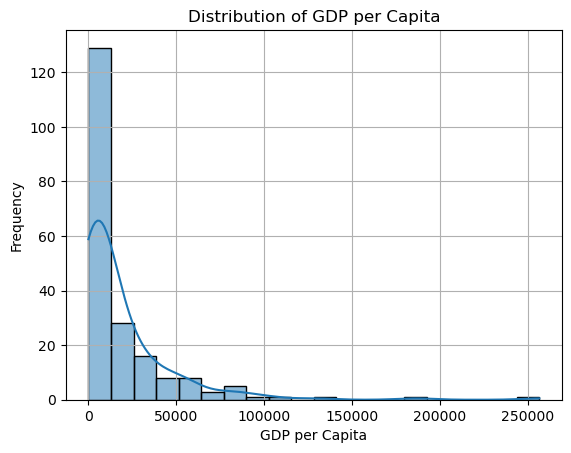

In [238]:
# Lets create a histogram of the GDP per Capita to see the distribution of the data
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['GDP per Capita'], bins=20, kde=True)
plt.xlabel('GDP per Capita')
plt.ylabel('Frequency')
plt.title('Distribution of GDP per Capita')
plt.grid(True)

plt.show()

# We observe that the GDP per Capita is right skewed!
# How sad it is to see that the world is so unequal! :(


In [239]:
df['GDP per Capita'].describe()

count       202.000000
mean      18855.371496
std       30356.830197
min         193.007146
25%        2478.681863
50%        7153.966921
75%       22412.598990
max      256580.515123
Name: GDP per Capita, dtype: float64

In [240]:
# Lets create a new column called GDP per Capita Class
# We shall classify the GDP per Capita into 4 classes as per World Bank classification
# Low Income, Lower Middle Income, Upper Middle Income and High Income
df['GDP per Capita Class'] = pd.cut(df['GDP per Capita'], bins=[0, 1135, 4465, 13845, 256581],labels=['Low Income', 'Lower Middle Income', 'Upper Middle Income', 'High Income'])
gdp_class_summary = df['GDP per Capita Class'].value_counts(normalize=True)*100
print(gdp_class_summary)

df.head()

GDP per Capita Class
High Income            34.158416
Lower Middle Income    27.227723
Upper Middle Income    27.227723
Low Income             11.386139
Name: proportion, dtype: float64


,Country,Government revenue as % of GDP\n2015–2023 (R),Over All Expenditure_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,ODA inflow,ODA inflow_GNI,ODA outflow,GDP per Capita,GDP per Capita Class
0,Afghanistan,13.0,21.8,0.7,4.3,1.4,3960.0,26.8,NaN,415.707417,Low Income
1,Albania,19.3,11.1,2.9,2.7,1.9,339.0,1.7,NaN,8575.171134,Upper Middle Income
2,Algeria,NaN,16.9,3.3,6.3,2.3,233.0,0.1,NaN,5364.027950,Upper Middle Income
3,Andorra,NaN,NaN,6.2,2.7,NaN,NaN,NaN,NaN,46812.448449,High Income
4,Angola,21.8,6.4,1.7,2.3,0.5,97.0,0.1,NaN,2308.159767,Lower Middle Income


In [417]:
country_gdp_class = df[['Country','GDP per Capita Class']]
country_gdp_class.head()

,Country,GDP per Capita Class
0,Afghanistan,Low Income
1,Albania,Upper Middle Income
2,Algeria,Upper Middle Income
3,Andorra,High Income
4,Angola,Lower Middle Income


In [269]:
#renaming the first column to remove % sign
df.rename(columns={df.columns[1]:'Govt Rev_GDP'}, inplace=True)

In [ ]:
# Treating the missing values in the column Government revenue as a % of GDP
# We shall replace the missing values with the median of the GDP per Capita class, 
# median is more suitable than mean when data is skewed and its percentage
median_revenue = pd.DataFrame(df.iloc[:,1].groupby(df['GDP per Capita Class']).median(),
                              index=['Low Income', 'Lower Middle Income', 'Upper Middle Income', 'High Income'])


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_54289/2511588033.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_revenue = pd.DataFrame(df.iloc[:,1].groupby(df['GDP per Capita Class']).median(),


In [ ]:
median_revenue

# Table shows the median of the Government Revenue as a % of GDP for each GDP per Capita class
# We shall replace the missing values with the median of the GDP per Capita class

,Govt Rev_GDP
Low Income,14.2
Lower Middle Income,19.9
Upper Middle Income,23.1
High Income,26.0


In [302]:
# Lets replace the missing values in the column Government revenue as a % of GDP by using the median


for i in range(len(df)):
    if pd.isnull(df.iloc[i,1]):
        if df['GDP per Capita Class'][i] == 'Low Income':
            df.iloc[i,1] = median_revenue.loc['Low Income'].values[0]
        elif df['GDP per Capita Class'][i] == 'Lower Middle Income':
            df.iloc[i,1] = median_revenue.loc['Lower Middle Income'].values[0]
        elif df['GDP per Capita Class'][i] == 'Upper Middle Income':
            df.iloc[i,1] = median_revenue.loc['Upper Middle Income'].values[0]
        else:
            df.iloc[i,1] = median_revenue.loc['High Income'].values[0]


In [ ]:
df.isnull().sum()

# Government Revenue as a % of GDP has no missing values now!


Country                                0
Govt Rev_GDP                           0
Over All Expenditure_GDP              34
Health Expenditure_GDP                14
Education Expenditure_GDP             26
social protection expenditure_GDP     90
ODA inflow                            63
ODA inflow_GNI                        66
ODA outflow                          171
GDP per Capita                         0
GDP per Capita Class                   0
dtype: int64

In [305]:
df.head() # Keep relooking at the data to see if it is shaping up as per our expectations!

,Country,Govt Rev_GDP,Over All Expenditure_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,ODA inflow,ODA inflow_GNI,ODA outflow,GDP per Capita,GDP per Capita Class
0,Afghanistan,13.0,21.8,0.7,4.3,1.4,3960.0,26.8,NaN,415.707417,Low Income
1,Albania,19.3,11.1,2.9,2.7,1.9,339.0,1.7,NaN,8575.171134,Upper Middle Income
2,Algeria,23.1,16.9,3.3,6.3,2.3,233.0,0.1,NaN,5364.027950,Upper Middle Income
3,Andorra,26.0,NaN,6.2,2.7,NaN,NaN,NaN,NaN,46812.448449,High Income
4,Angola,21.8,6.4,1.7,2.3,0.5,97.0,0.1,NaN,2308.159767,Lower Middle Income


In [308]:
def fill_na(df, col_name):
    median_col = pd.DataFrame(df[col_name].groupby(df['GDP per Capita Class']).median(),
                              index=['Low Income', 'Lower Middle Income', 'Upper Middle Income', 'High Income'])
    for i in range(len(df)):
        if pd.isnull(df.loc[i,col_name]):
            if df['GDP per Capita Class'][i] == 'Low Income':
                df.loc[i,col_name] = median_col.loc['Low Income'].values[0]
            elif df['GDP per Capita Class'][i] == 'Lower Middle Income':
                df.loc[i,col_name] = median_col.loc['Lower Middle Income'].values[0]
            elif df['GDP per Capita Class'][i] == 'Upper Middle Income':
                df.loc[i,col_name] = median_col.loc['Upper Middle Income'].values[0]
            else:
                df.loc[i,col_name] = median_col.loc['High Income'].values[0]
    return df

In [ ]:
# Lets fill the missing values in columns 1,2,3,4 and 5
for i in range(1,6):
    df = fill_na(df,df.columns[i])


print(df.isnull().sum())

# Hence the first 5 columns have no missing values now!
# They have been filled with the median of the column for the respective GDP per Capita class!

Country                                0
Govt Rev_GDP                           0
Over All Expenditure_GDP               0
Health Expenditure_GDP                 0
Education Expenditure_GDP              0
social protection expenditure_GDP      0
ODA inflow                            63
ODA inflow_GNI                        66
ODA outflow                          171
GDP per Capita                         0
GDP per Capita Class                   0
dtype: int64


/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_54289/864738942.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_col = pd.DataFrame(df[col_name].groupby(df['GDP per Capita Class']).median(),
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_54289/864738942.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_col = pd.DataFrame(df[col_name].groupby(df['GDP per Capita Class']).median(),
/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_54289/864738942.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of p

In [313]:
df.head()

,Country,Govt Rev_GDP,Over All Expenditure_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,ODA inflow,ODA inflow_GNI,ODA outflow,GDP per Capita,GDP per Capita Class
0,Afghanistan,13.0,21.8,0.7,4.3,1.4,3960.0,26.8,NaN,415.707417,Low Income
1,Albania,19.3,11.1,2.9,2.7,1.9,339.0,1.7,NaN,8575.171134,Upper Middle Income
2,Algeria,23.1,16.9,3.3,6.3,2.3,233.0,0.1,NaN,5364.027950,Upper Middle Income
3,Andorra,26.0,19.8,6.2,2.7,1.2,NaN,NaN,NaN,46812.448449,High Income
4,Angola,21.8,6.4,1.7,2.3,0.5,97.0,0.1,NaN,2308.159767,Lower Middle Income


In [314]:
# Going with our thumb rule of keeping only the columns which are a proportion of GDP/GNI,
# we shall drop the columns which are not a proportion of GDP/GNI i.e ODA inflow, ODA outflow 
df.drop(['ODA inflow','ODA outflow'], axis=1, inplace=True)

In [315]:
# For the missing values of ODA inflow_GNI, we shall replace missing values by 0
# If a country does not receive any ODA inflow, it is as good as 0
df['ODA inflow_GNI'].fillna(0, inplace=True)

/var/folders/qx/bz1vynbj5_g5cg431gd5_s7h0000gn/T/ipykernel_54289/4271625336.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ODA inflow_GNI'].fillna(0, inplace=True)


In [316]:
df.head()

,Country,Govt Rev_GDP,Over All Expenditure_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,ODA inflow_GNI,GDP per Capita,GDP per Capita Class
0,Afghanistan,13.0,21.8,0.7,4.3,1.4,26.8,415.707417,Low Income
1,Albania,19.3,11.1,2.9,2.7,1.9,1.7,8575.171134,Upper Middle Income
2,Algeria,23.1,16.9,3.3,6.3,2.3,0.1,5364.027950,Upper Middle Income
3,Andorra,26.0,19.8,6.2,2.7,1.2,0.0,46812.448449,High Income
4,Angola,21.8,6.4,1.7,2.3,0.5,0.1,2308.159767,Lower Middle Income


In [ ]:
df.isnull().sum()

# So there is no missing value in the dataset now!
# Given the dataset is small, we couldnot afford to drop any rows! 
# So we plugged in every missing value, nurturing the data like our baby! :P
# Someone rightly said, "Data Cleaning is 80% of the work in Data Science!"
# The road to heaven passes through hell! :P

Country                              0
Govt Rev_GDP                         0
Over All Expenditure_GDP             0
Health Expenditure_GDP               0
Education Expenditure_GDP            0
social protection expenditure_GDP    0
ODA inflow_GNI                       0
GDP per Capita                       0
GDP per Capita Class                 0
dtype: int64

In [318]:
# Lets write this dataframe df to a csv file for analysis in the future!
df.to_csv('UNICEF data cleaned.csv', index=False)

# Exploratory Data Analysis

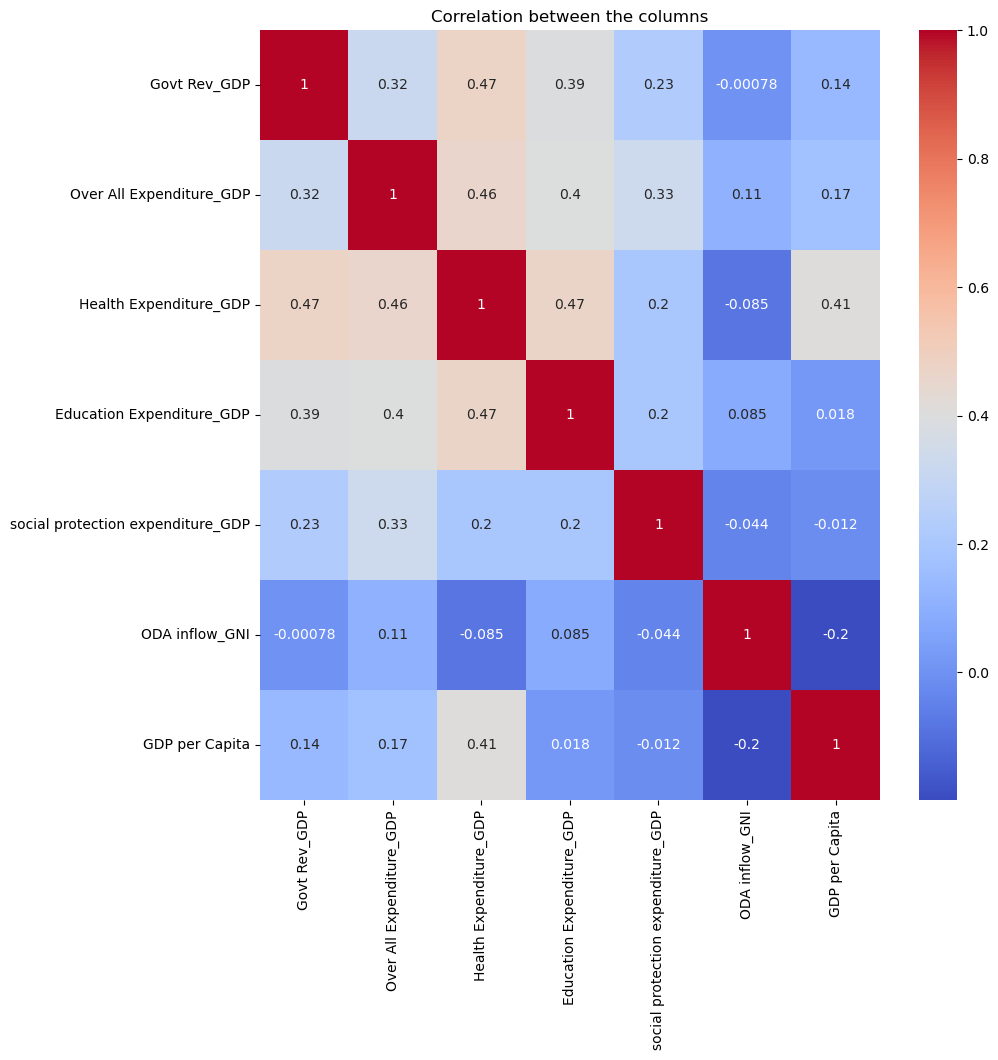

In [ ]:
# Lets do some exploratory data analysis now!     
# Lets see the correlation between the columns
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation between the columns')
plt.show()

# Largely the correlations seem to be low.

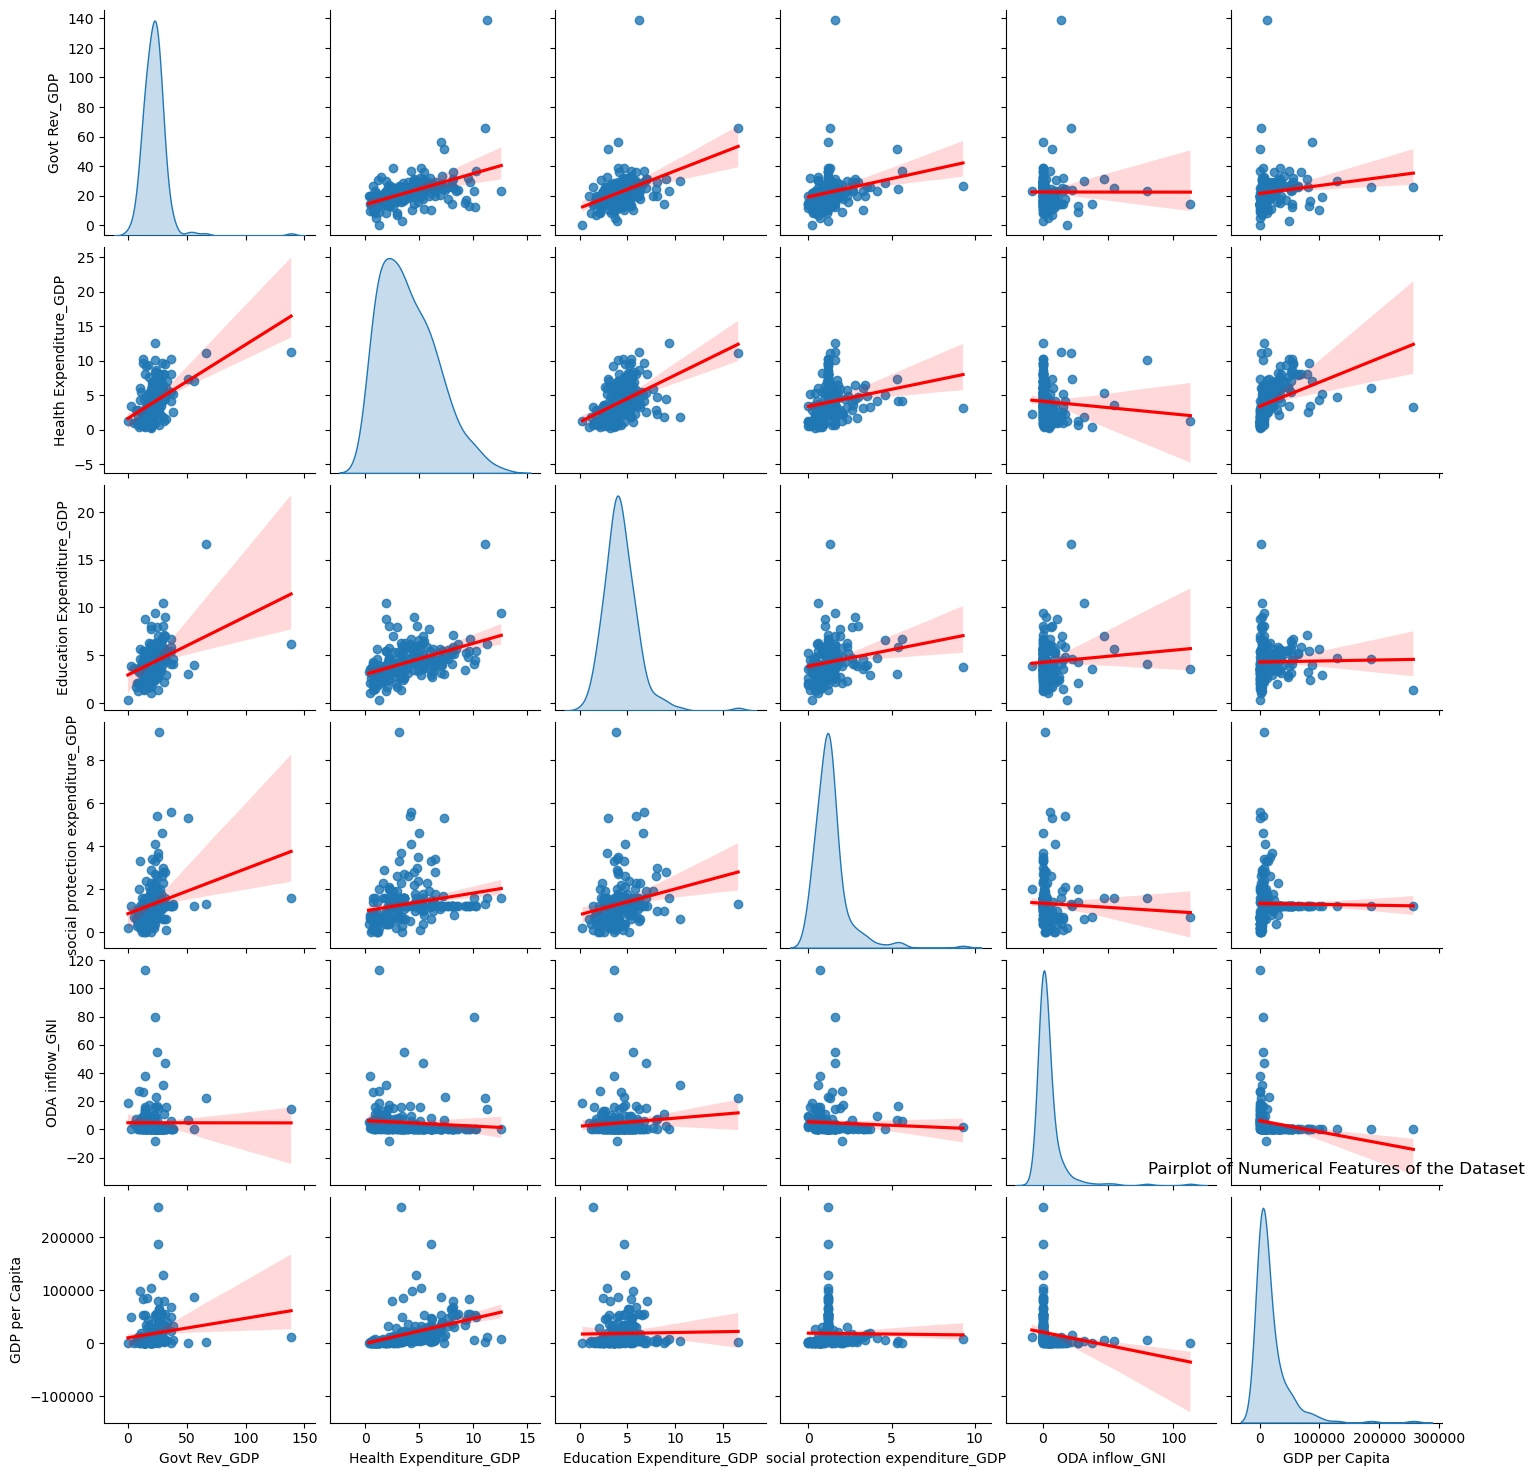

In [332]:
# Lets create pairplots to see the relationship between the columns
sns.pairplot(df.select_dtypes(include=[np.number]), diag_kind='kde', kind='reg',
              plot_kws={'line_kws': {'color': 'red'}},
             ) 

plt.title('Pairplot of Numerical Features of the Dataset')
plt.show()

In [324]:
# The pairplot shows the the Over All Expenditure as a % of GDP has a linear relationship with the other Expenditure columns ( Quite Obvious! :P)
# Lets drop the Over All Expenditure as a % of GDP column as it is a sum of the other Expenditure columns
df.drop('Over All Expenditure_GDP', axis=1, inplace=True)
df.head()

,Country,Govt Rev_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,ODA inflow_GNI,GDP per Capita,GDP per Capita Class
0,Afghanistan,13.0,0.7,4.3,1.4,26.8,415.707417,Low Income
1,Albania,19.3,2.9,2.7,1.9,1.7,8575.171134,Upper Middle Income
2,Algeria,23.1,3.3,6.3,2.3,0.1,5364.027950,Upper Middle Income
3,Andorra,26.0,6.2,2.7,1.2,0.0,46812.448449,High Income
4,Angola,21.8,1.7,2.3,0.5,0.1,2308.159767,Lower Middle Income


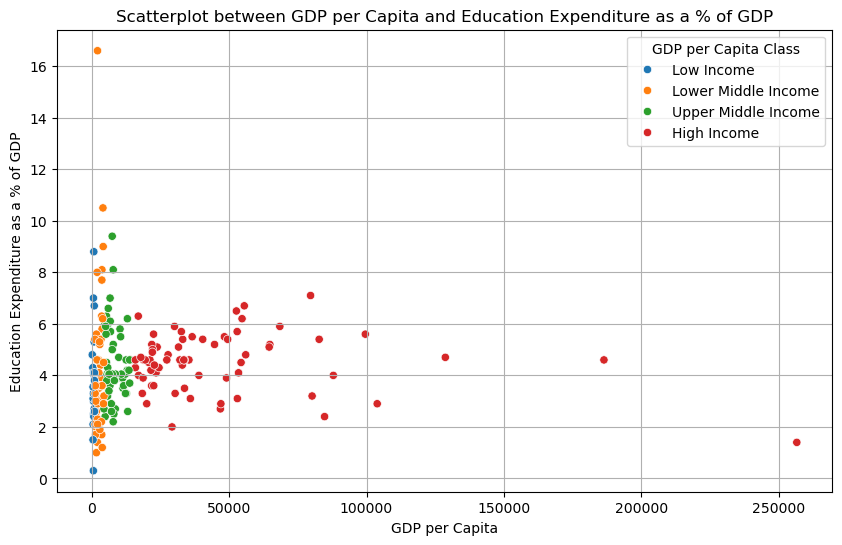

In [ ]:
# Lets make a scatterplot between GDP per capita and the
#  Education expenditure as a % of GDP
plt.figure(figsize=(10,6))
sns.scatterplot(x='GDP per Capita', y='Education Expenditure_GDP', data=df,hue='GDP per Capita Class')
plt.xlabel('GDP per Capita')
plt.ylabel('Education Expenditure as a % of GDP')
plt.title('Scatterplot between GDP per Capita and Education Expenditure as a % of GDP')
plt.grid(True)
plt.show()

# Do you see how clearly these data points are separated into 4 classes?
# This is the power of GDP per Capita! It is a very important feature!
# It is the mother of all features! :P

# Standardize the Variables

In [336]:
from sklearn.preprocessing import StandardScaler

In [337]:
#Create a StandardScaler object
scaler = StandardScaler()

In [338]:
# fitting and transforming the dataset using the scaler
scaled_X = scaler.fit_transform(df.drop(['Country','GDP per Capita Class','GDP per Capita'], axis=1))

In [ ]:
df_scaled = pd.DataFrame(scaled_X, columns=df.columns[1:-2])
df_scaled.head()

# So we have scaled the data now!

,Govt Rev_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,ODA inflow_GNI
0,-0.819060,-1.272627,-0.003012,0.065437,1.829331
1,-0.275497,-0.432464,-0.887972,0.534172,-0.247070
2,0.052366,-0.279708,1.103188,0.909160,-0.379430
3,0.302577,0.827779,-0.887972,-0.122057,-0.387702
4,-0.059798,-0.890735,-1.109212,-0.778286,-0.379430


# Train Test Split

In [340]:
from sklearn.model_selection import train_test_split

In [341]:
X_train, X_test, y_train, y_test = train_test_split(df_scaled, df['GDP per Capita Class'], 
                                                    test_size=0.2, random_state=42)

# Using KNN

In [342]:
# importing the KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

# Choosing a K Value

We use the elbow method to pick a good K value!

In [343]:
error_rate = [] # to store the error rate for different values of k
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i) # creating an instance of the KNeighborsClassifier
    
    knn.fit(X_train, y_train)  # fitting the model to training data
    
    pred_i = knn.predict(X_test)  # predicting the model on the test data

    error_rate.append(np.mean(pred_i != y_test))  # storing error rate for the current k value

    

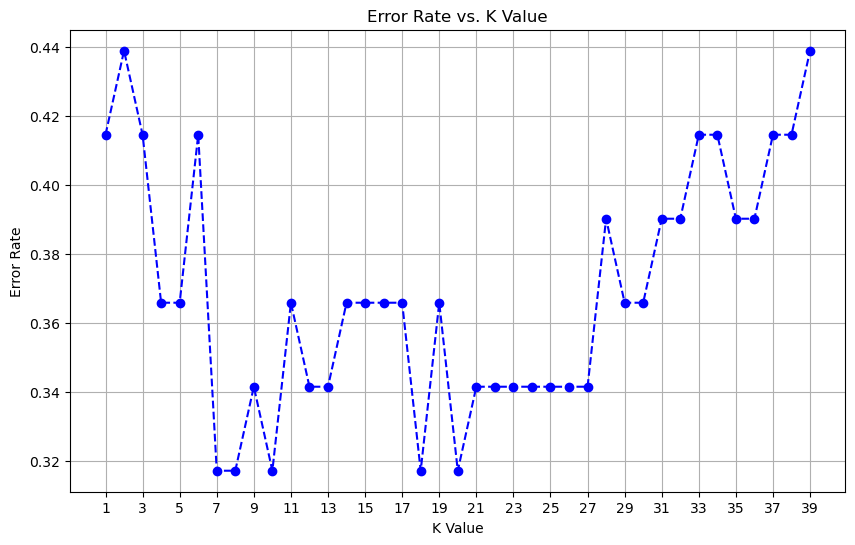

In [344]:
# Plotting the error rate vs k values
plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rate, color='blue', linestyle='dashed', marker='o')
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(range(1,40,2))
plt.grid()
plt.show()

We consider k = 18 for which the error rate is low

In [345]:
# Now with K = 18, we shall train the model and make predictions
knn = KNeighborsClassifier(n_neighbors=18)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)   


# Evaluations and Predictions

In [346]:
from sklearn.metrics import classification_report, confusion_matrix


In [347]:
print("Confusion Matrix: \n", confusion_matrix(y_test, predictions))
print("\n")
print("Classification Report: \n", classification_report(y_test, predictions))

Confusion Matrix: 
 [[10  0  0  2]
 [ 0  2  0  0]
 [ 3  0  8  3]
 [ 4  0  1  8]]


Classification Report: 
                      precision    recall  f1-score   support

        High Income       0.59      0.83      0.69        12
         Low Income       1.00      1.00      1.00         2
Lower Middle Income       0.89      0.57      0.70        14
Upper Middle Income       0.62      0.62      0.62        13

           accuracy                           0.68        41
          macro avg       0.77      0.76      0.75        41
       weighted avg       0.72      0.68      0.68        41



Oops! Such a low accuracy of 68%. Not good. What could go wrong? Probably we could consider a lower k given the small dataset.

In [348]:
# Lets do it with k = 7
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)


In [349]:
# Evaluating the model with k = 7
print("Confusion Matrix: \n", confusion_matrix(y_test, predictions))
print("\n") 
print("Classification Report: \n", classification_report(y_test, predictions))

Confusion Matrix: 
 [[10  0  0  2]
 [ 0  1  1  0]
 [ 3  0  9  2]
 [ 4  0  1  8]]


Classification Report: 
                      precision    recall  f1-score   support

        High Income       0.59      0.83      0.69        12
         Low Income       1.00      0.50      0.67         2
Lower Middle Income       0.82      0.64      0.72        14
Upper Middle Income       0.67      0.62      0.64        13

           accuracy                           0.68        41
          macro avg       0.77      0.65      0.68        41
       weighted avg       0.71      0.68      0.68        41



Even k = 7 is not improving the accuracy. Let us refine our Target Variable into 2 colums and not 4.

Creating a new Target Variable : Developed and Underdeveloped
1. Developed --> Developed Country  --> High Income & Upper Middle Income
2. Underdeveloped --> Underdeveloped Country  --> Low Income & Lower Middle Income

In [403]:
df['Dev_Status'] = df['GDP per Capita Class'].map({'Low Income':'Developing', 
                                                   'Lower Middle Income':'Developing', 
                                                   'Upper Middle Income':'Developed', 
                                                   'High Income':'Developed'})

In [404]:
df.head()

,Country,Govt Rev_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,ODA inflow_GNI,GDP per Capita,GDP per Capita Class,Dev_Status
0,Afghanistan,13.0,0.7,4.3,1.4,26.8,415.707417,Low Income,Developing
1,Albania,19.3,2.9,2.7,1.9,1.7,8575.171134,Upper Middle Income,Developed
2,Algeria,23.1,3.3,6.3,2.3,0.1,5364.027950,Upper Middle Income,Developed
3,Andorra,26.0,6.2,2.7,1.2,0.0,46812.448449,High Income,Developed
4,Angola,21.8,1.7,2.3,0.5,0.1,2308.159767,Lower Middle Income,Developing


Text(0.5, 1.0, 'Scatterplot between Government Revenue as a % of GDP and Education Expenditure as a % of GDP')

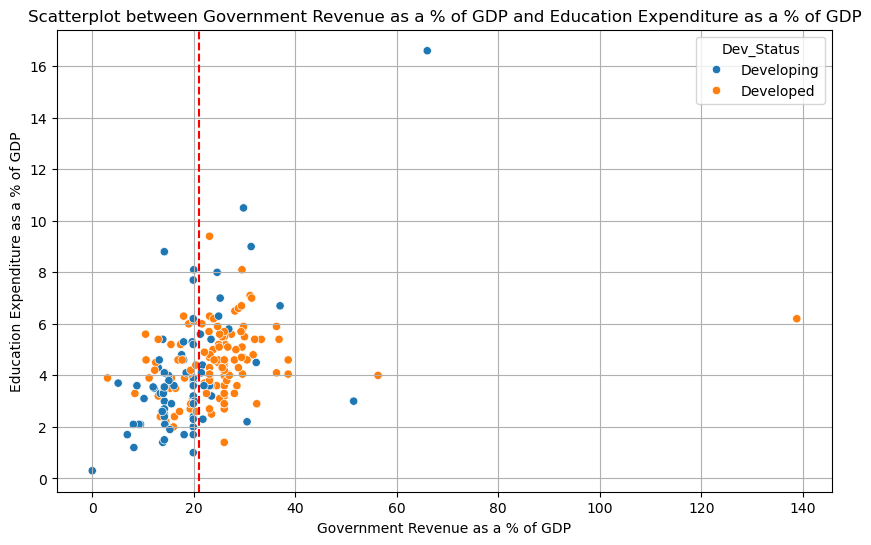

In [ ]:
# Make a scatter plot between Government Revenue as a % of GDP and Education Expenditure as a % of GDP
plt.figure(figsize=(10,6))
sns.scatterplot(x='Govt Rev_GDP', y='Education Expenditure_GDP', data=df, hue='Dev_Status')
plt.xlabel('Government Revenue as a % of GDP')
plt.ylabel('Education Expenditure as a % of GDP')
# plotting a vertical line x = 21
plt.axvline(x=21, color='red', linestyle='--', label='Rough Linear Separation')  
plt.grid(True)
plt.title('Scatterplot between Government Revenue as a % of GDP and Education Expenditure as a % of GDP')

# There is a slight linear separation between the Developing and Developed countries


Training and Testing Data with new Target Variable

In [405]:
X_train,X_test,y_train,y_test = train_test_split(df_scaled, df['Dev_Status'],
                                                  test_size=0.2, random_state=42)

In [406]:
error_rate = [] # to store the error rate for different values of k
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i) # creating an instance of the KNeighborsClassifier
    
    knn.fit(X_train, y_train)  # fitting the model to training data
    
    pred_i = knn.predict(X_test)  # predicting the model on the test data

    error_rate.append(np.mean(pred_i != y_test))  # storing error rate for the current k value

    

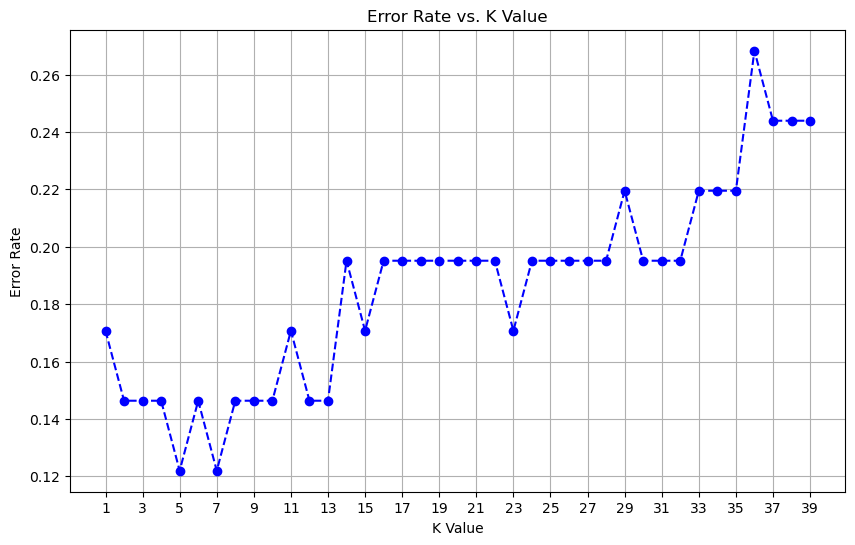

In [407]:
# Plotting the error rate vs k values
plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rate, color='blue', linestyle='dashed', marker='o')
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(range(1,40,2))
plt.grid()
plt.show()

# Final Model with K = 5 and Target Variables having 2 Classes

In [408]:
# Now with K = 5, we shall train the model and make predictions
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)

In [409]:
# Creating confusion matrix and classification report
print("Confusion Matrix: \n", confusion_matrix(y_test, predictions))
print("\n")
print("Classification Report: \n", classification_report(y_test, predictions))

Confusion Matrix: 
 [[24  1]
 [ 4 12]]


Classification Report: 
               precision    recall  f1-score   support

   Developed       0.86      0.96      0.91        25
  Developing       0.92      0.75      0.83        16

    accuracy                           0.88        41
   macro avg       0.89      0.85      0.87        41
weighted avg       0.88      0.88      0.88        41



# What a beautiful Accuracy of 88%. Not bad considering the filthy data we had got!


# Now let's see a practical implication of it :

Our Nation aims to be a Viksit Bharat at 2047. So what data can we plug in to reach the status of Developed Country?

The features which we consider here :
1. Government Revenue as % of GDP
2. Health Expenditure as a % of GDP
3. Education Expenditure as a % of GDP
4. Social Protection Expenditure as a % of GDP
5. ODA inflow as a % of GNI

So as a common man, I dont want to be taxed, lets keep the Government Revenue at a decent 12%. However as per National Health Policy, we can consider Health Expenditure to be 3% of GDP, whereas as per National Education Policy we can consider Expenditure on Education as 6% of GDP. Even the social protection expenditure to enhance jobs and pensions must increase to 5% of GDP. If we are aiming to become a superpower we should not ask for Official Development Assistance, rather have joint projects with Japan, UAE, Korea, Israel, etc. Hence I will take ODA as 0%.



In [410]:
# Considering the visionary investments on health, education and social protection
X_India = np.array([[12,3,6,5,0]])
X_India = scaler.transform(X_India)


/Users/shaarifakhtar/Documents/python/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [413]:
# Predicting the development status of India
#ignore warnings by importing the warnings module
import warnings
warnings.filterwarnings("ignore")
development_status = knn.predict(X_India)[0]
print(f"The predicted development status of India is: {development_status}")

The predicted development status of India is: Developed


Congratulations, we found a practical implication of Classification by KNN.